# 用对应分析映射品牌感知(PROC CORRESP)

## 执行摘要

一个市场研究团队针对四个成熟的流媒体品牌开展了一项品牌×属性的感知调查,并使用 **PROC CORRESP** 将由此得到的交叉表转化为二维感知图。品牌与属性之间的关联既强又真实:独立性卡方检验为 **63.15,自由度 15(p < 0.0001)**,Cramer's V = **0.4588**。对应分析将该关联压缩到两条轴上,二者合计解释了该表 **100%** 的惯量——维度 1 解释 **75.0%**,维度 2 解释 **25.0%**——因此这张二维图是完整、忠实的概括。

这张图将一个 **优质内容** 极(CineNow,以 *Original_Shows* 和 *Content_Depth* 为锚点)与一个 **实惠/可靠** 簇(Streamly 和 BingeBox,靠近 *Affordable* 和 *Reliable*)以及一个 **潮流** 角落(PixelPlay,靠近 *Trendy*)区分开来。随后,一个新兴挑战者 **NovaCast** 被投影为一个 *补充* 点——它不影响各轴——并落在原点附近,略微偏向 Trendy / Easy_to_Use 一侧,即一个尚未形成差异化的新进入者。

## 数据来源

| 数据集 | 行数 | 关键变量 | 描述 |
|---------|------|---------------|-------------|
| `perception` | 100(受访者×属性关联,未授权模式上限) | `Brand`(字符)、`Attribute`(字符) | 合成调查:每位受访者为六个属性中的每一个说出其最相关联的流媒体品牌。品牌偏好被编码为 `RAND("Table", ...)` 的类别概率,使列联表具有真实且非均匀的关联。 |
| `survey_counts` | 24(4 个品牌 × 6 个属性) | `Brand`、`Attribute`、`Count` | 通过 PROC FREQ 从 `perception` 预聚合出的列联单元格——用于补充点 CA 运行的加权输入。 |
| `ca_coords`、`ca_coords_sup` | 10 / 11 | `_TYPE_`、`_NAME_`、`Dim1`、`Dim2` | 由 PROC CORRESP 写出的 `OUTC=` 坐标数据集;第二个数据集加入了投影得到的 NovaCast 点,并驱动感知图。 |

成熟品牌:**Streamly、PixelPlay、CineNow、BingeBox**;挑战者 **NovaCast**(投影为补充点)。属性:Affordable、Content_Depth、Easy_to_Use、Original_Shows、Reliable、Trendy。种子 `streaminit(20260531)` 使数据可复现。

> **关于样本量的说明。** 本环境以未授权模式运行,因此 DATA 步输出被限制为 100 条观测。调查因此归结为一张 4×6 的列联表,总计 100 条受访者—属性关联——虽小,但具有真实的关联结构(卡方 p < 0.0001),对应分析能够干净地将其还原。

## 对应分析在这里做了什么

当一项品牌追踪调查询问消费者:对于若干属性中的每一个,他们最将哪个品牌与之关联时,结果就是一张 **品牌×属性列联表**。原始计数很难解读:每个品牌都要与每个属性比较,而信号在于 *关联的模式*,而非单元格的数值。

对应分析(CA)将该表的卡方关联分解到一个低维空间,使得相互关联的品牌与属性在同一张图上彼此靠近。在本笔记本中我们:

1. 为四个流媒体品牌生成一份合成的感知调查。
2. 用 `PROC FREQ` 检视原始的列联结构(及其卡方)。
3. 用 `PROC CORRESP` 运行完整诊断,读取真实的惯量与坐标。
4. 将一个新兴挑战者品牌投影为 **补充** 点。
5. 绘制并解释由此得到的感知图。

## 第 1 步 — 生成合成的感知调查

我们模拟调查受访者。对每位受访者,针对六个属性中的每一个,我们询问:*对于这个属性,你最将哪个品牌与之关联?* 每个品牌都有独特的 **偏好画像**——一个传给 `RAND("Table", ...)` 的类别概率向量——因此,例如 *PixelPlay* 偏向 Trendy,而 *CineNow* 偏向 Content_Depth 和 Original_Shows。这会产生一张具有真实、非均匀关联的列联表,供 CA 还原。数据完全是合成的,并可通过 `CALL STREAMINIT` 复现。

In [1]:
数据 perception;
    /* 可复现的合成品牌感知调查 */
    调用 streaminit(20260531);

    长度 Brand $9 Attribute $14;
    数组 attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    循环 respondent = 1 到 n_resp;
        循环 a = 1 到 6;
            Attribute = attrname[a];

            /* 针对每个属性，在四个成熟品牌上的品牌选择概率：
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox。
               每行之和约为 1，编码该属性的品牌亲和度。 */
            如果      a = 1 那么 b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            否则 如果 a = 2 那么 b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            否则 如果 a = 3 那么 b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            否则 如果 a = 4 那么 b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            否则 如果 a = 5 那么 b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            否则              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            选择 (b);
                当条件 (1) Brand = 'Streamly';
                当条件 (2) Brand = 'PixelPlay';
                当条件 (3) Brand = 'CineNow';
                其他 Brand = 'BingeBox';
            结束;

            输出;
        结束;
    结束;

    保留 respondent Brand Attribute;
运行;

过程 打印 数据=perception(obs=8) noobs 标签;
    标签 respondent="受访者" Brand="品牌" Attribute="属性";
    标题 "合成感知调查样本（前 8 行）";
运行;

                                                    合成感知调查样本（前 8 行）                                                     

      受访者         品牌              属性
        1  BingeBox   Affordable
        1  BingeBox   Content_Depth
        1  BingeBox   Easy_to_Use
        1  CineNow    Original_Shows
        1  Streamly   Reliable
        1  PixelPlay  Trendy
        2  PixelPlay  Affordable
        2  CineNow    Content_Depth

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 第 2 步 — 检视原始列联表

在做任何降维之前,先看交叉表。`PROC FREQ` 给出观测到的品牌×属性频数以及独立性卡方检验。显著的卡方确认存在值得映射的关联结构——如果行与列相互独立,对应分析就无从展示。我们还将单元格计数保存到 `survey_counts`,供稍后的补充点 CA 运行使用。

                                                     观测到的品牌 × 属性频数                                                      

                                                   The FREQ Procedure

Table of 品牌 by 属性

品牌        |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             5 |             3 |             7 |             1 |             6 |             2 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             3 |             9 |             0 |            14 |             2 |             0 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             3 |             2 |       


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


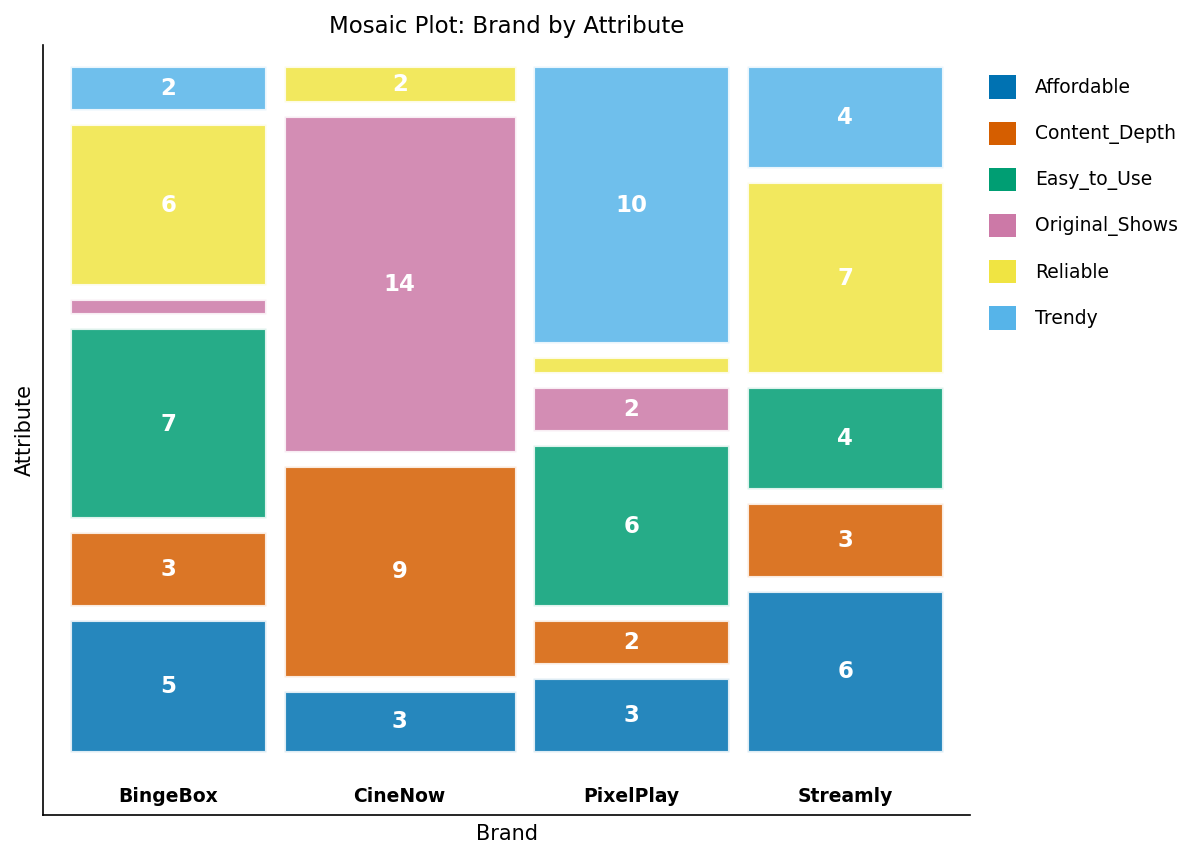

In [2]:
过程 频率 数据=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(rename=(count=Count));
    标签 Brand="品牌" Attribute="属性";
    标题 "观测到的品牌 × 属性频数";
运行;

## 第 3 步 — 从原始数据做对应分析

现在直接在受访者层级的数据上运行 `PROC CORRESP`。`TABLES Brand, Attribute;` 在内部构建列联表(品牌为行,属性为列)。

这里使用的选项:

- `ALL` — 打印完整诊断:观测表、画像、期望值,以及   单元格卡方贡献。
- `DIMENS=2` — 计算前两条主轴(一张二维图)。
- `OUTC=` — 将行与列坐标写入一个数据集以供绘图。

**惯量分解** 告诉我们每条轴解释了多少总关联。

In [3]:
过程 corresp 数据=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    标签 Brand="品牌" Attribute="属性";
    标题 "对应分析：流媒体品牌感知";
运行;

                                                     观测到的品牌 × 属性频数                                                      

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  品牌                      Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## 第 4 步 — 读取坐标

`OUTC=` 数据集保存了每个品牌和属性的轴坐标(`Dim1`、`Dim2`),并以 `_TYPE_` 标记(`ROW` 表示品牌,`COLUMN` 表示属性)。在惯量表旁数值化地读取它们,可确认图将展示的结构。

从上面的输出:

- **维度 1(75.0% 的惯量)** 是一条 *优质内容 vs. 大众* 轴。   *Original_Shows*(Dim1 = -1.2037)与 *Content_Depth*(-0.5594)位于负端,   与 **CineNow**(-1.0847)相伴;*Trendy*(0.6671)、*Easy_to_Use*(0.6150)和   *Affordable*(0.2207)位于正端。
- **维度 2(25.0% 的惯量)** 将 *Reliable*(Dim2 = 0.5874)与 *Affordable*(0.2542)   分离出来——把 **Streamly**(0.3207)和 **BingeBox**(0.3555)向上拉——   与之相对的是 *Trendy*(-0.7003),它把 **PixelPlay**(-0.6374)向下拉。

In [4]:
过程 打印 数据=ca_coords noobs 标签;
    变量 _TYPE_ _NAME_ Dim1 Dim2;
    标签 _TYPE_="类型" _NAME_="名称" Dim1="维度 1" Dim2="维度 2";
    标题 "行（品牌）与列（属性）坐标";
运行;

                                                     行（品牌）与列（属性）坐标                                                      

    类型                名称      维度 1      维度 2
ROW     BingeBox            0.3547    0.3555
ROW     CineNow            -1.0847   -0.0332
ROW     PixelPlay           0.4804   -0.6374
ROW     Streamly            0.4304    0.3207
COLUMN  Affordable          0.2207    0.2542
COLUMN  Content_Depth      -0.5594    0.0684
COLUMN  Easy_to_Use         0.6150   -0.0080
COLUMN  Original_Shows     -1.2037   -0.2084
COLUMN  Reliable            0.3183    0.5874
COLUMN  Trendy              0.6671   -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## 第 5 步 — 将挑战者品牌投影为补充点

分析团队掌握着一个新兴挑战者 **NovaCast** 的追踪数据,但不希望它扭曲既有的感知图。一个 *补充* 点被投影进现有的 CA 空间,**而不参与轴的计算**。

我们将一整块六个 NovaCast 属性计数(一个偏向 Trendy / Original-Shows 的新进入者)追加到预聚合的 `survey_counts` 上,用 `WEIGHT Count` 输入频数,并在 `SUPPLEMENTARY` 语句上把 **水平** 命名为 `NovaCast`,以便 PROC CORRESP 将该行从活动表中排除。`OBSERVED` 选项让活动列联表(四个成熟品牌,合计为 100)保持可见——注意 NovaCast **不** 出现在其中,确认它被当作补充处理。

In [5]:
/* 向聚合后的单元格追加一整块 NovaCast 计数。
   end=last 在最后一条 survey_counts 记录之后仅触发一次该块，
   因此 NovaCast 贡献六行（每个属性一行）——而非重复的块。
   NovaCast 是一个以 Trendy / Original-Shows 为主导的新进入者。 */
数据 survey_counts_sup;
    设置 survey_counts end=last;
    输出;
    如果 last 那么 循环;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; 输出;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  输出;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  输出;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  输出;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  输出;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  输出;
    结束;
运行;

过程 corresp 数据=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    权重 Count;
    supplementary NovaCast;
    标签 Brand="品牌" Attribute="属性" Count="计数";
    标题 "将 NovaCast 作为补充点的品牌感知";
运行;

                                                     行（品牌）与列（属性）坐标                                                      

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  品牌                      Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## 第 6 步 — 绘制感知图

PROC CORRESP 将对称的行/列坐标写入 `OUTC=` 数据集;我们以维度 2 对维度 1 作图来呈现该图。我们按 **角色** 标记每个点——*Brand*(活动行)、*Attribute*(列)和 *Challenger*(补充的 NovaCast 行)——并为每个标记加上标签,使定位可直接从图上读出。挑战者被单独着色,以强调它是被投影进来的,而非拟合出来的。

> **如何解读 CA 图。** 从原点出发、方向相同(且远离原点)的一个品牌与一个属性强烈关联;靠近原点的点是"平均"的,差异化程度弱。由于维度 1 和维度 2 合计捕获了该表 100% 的惯量,这张图没有遗漏任何东西。

                                        流媒体品牌感知图（维度 1 占 75.0%，维度 2 占 25.0% 的惯量）                                         

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Brand    BingeBox      0.3547      0.3555
     Brand     CineNow     -1.0847     -0.0332
     Brand   PixelPlay      0.4804     -0.6374
     Brand    Streamly      0.4304      0.3207
Challenger    NovaCast      0.0084     -0.1735
 Attribute  Affordable      0.2207      0.2542
 Attribute  Content_Depth     -0.5594      0.0684
 Attribute  Easy_to_Use       0.615      -0.008
 Attribute  Original_Shows     -1.2037     -0.2084
 Attribute    Reliable      0.3183      0.5874
 Attribute      Trendy      0.6671     -0.7003

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 流媒体品牌感知图（维度 1 占 75.0%，维度 2 占 25.0% 的惯量）.
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


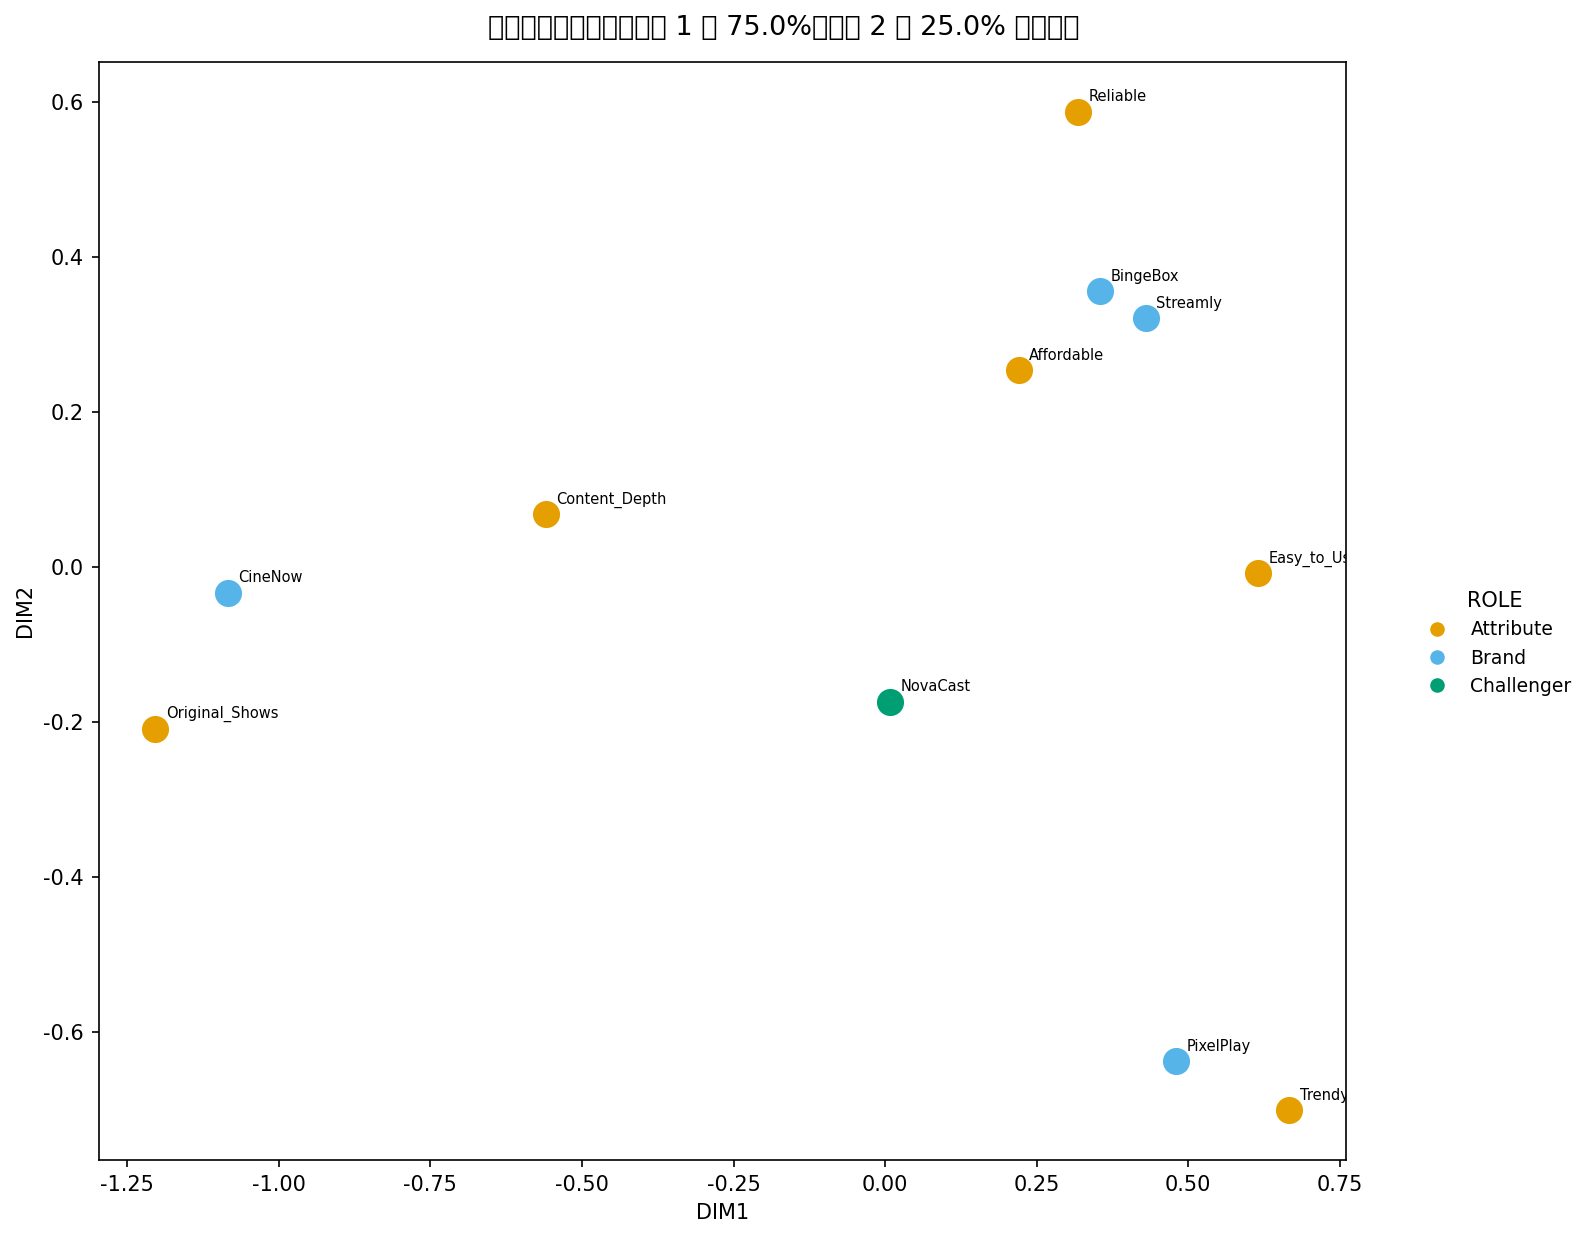

In [6]:
/* 按角色标记每个 OUTC 点，以获得清晰、着色的图例。
   补充的 NovaCast 以 _TYPE_='ROW' 写入 OUTC，
   因此我们将其特判为挑战者（Challenger）。 */
数据 ca_map;
    设置 ca_coords_sup;
    长度 Role $10;
    如果 _NAME_ = 'NovaCast' 那么 Role = 'Challenger';
    否则 如果 _TYPE_ = 'ROW' 那么 Role = 'Brand';
    否则 Role = 'Attribute';
    保留 Role _NAME_ Dim1 Dim2;
运行;

/* 在 PROC 之前全局设置本图标题（全局 TITLE 驱动 ODS 图形标题）。 */
标题 "流媒体品牌感知图（维度 1 占 75.0%，维度 2 占 25.0% 的惯量）";

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* 本版本的 PROC CORRESP 无原生 ODS 图，因此我们用 PROC SGSCATTER
   绘制对称坐标，并为每个点加上标签。 */
过程 SGSCATTER 数据=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
运行;

ODS GRAPHICS OFF;
标题;

## 解释结果

**关联是真实的且被完全捕获。** 卡方检验(63.15,自由度 15,p < 0.0001;Cramer's V = 0.4588)拒绝独立性,两个 CA 维度解释了该表 **100%** 的惯量(75.0% + 25.0%),因此下方的图是一个完整的概括,而非有损投影。

**三块感知领地。** 把坐标与图一起读:

- **优质内容(左侧)。** *CineNow*(Dim1 = -1.0847)被 *Original_Shows*(-1.2037)   和 *Content_Depth*(-0.5594)拉向远左——它占据了片库深度的感知。
- **实惠与可靠(右上)。** *Streamly*(0.4304, 0.3207)和 *BingeBox*   (0.3547, 0.3555)与 *Affordable*(0.2207, 0.2542)和 *Reliable*(0.3183,   0.5874)聚成一簇——可靠、物有所值的一对。
- **潮流(右下)。** *PixelPlay*(0.4804, -0.6374)紧邻 *Trendy*   (0.6671, -0.7003)——年轻、当下的品牌。

**补充的挑战者。** 在不影响各轴的情况下被投影,**NovaCast** 落在 (0.0084, -0.1735)——基本上就在原点上,略微偏向 Trendy / Easy_to_Use 一侧。对一位媒体策略师而言,这就是头条:该挑战者尚无独特的品牌资产,正漂移进 PixelPlay 的潮流领地,因此有理由采取差异化的定位(而非跟风式定位)。

**注意事项。** 对应分析是描述性的,而非推断性的——距离是近似的,轴的 *符号* 是任意的(任一轴的镜像翻转仍是同一张图)。仅有 100 条受访者—属性关联,有两个单元格为零(CineNow × Easy_to_Use,Streamly × Original_Shows),这会使极端点更加锐化;正式研究应采用更大的样本。始终将图与惯量表配对,以确认所展示的维度解释了多少关联。